## Add BioVariables to the **Final Dataset** and convert to **Annual** ##

In [1]:
import pandas as pd
import geopandas as gpd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys
from fuzzywuzzy import fuzz
import rpy2.robjects as robjects
import rpy2.ipython.html
from rpy2.robjects.packages import importr

rpy2.ipython.html.init_printing()

sys.path.insert(0, "../../../../Modules")

from utils import *


enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 20
#pd.options.display.float_format = lambda x: '%.6f' % x

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\rpy2\robjects\packages.py:367: UserWarning: The symbol 'quartz' is not in this R namespace/package.
  warnings.warn(


In [2]:
NUTS0 = 'GR'
NUTS2 = 'Attica'
NUTS2_ID = 'EL30'

In [3]:
dataset_monthly = pd.read_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_NUTS3_2009_2023.csv", encoding = enc)
dataset_monthly

,dt_placement,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,month,year,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_night_mean,lst_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,lw,monthly_lst_min,monthly_lst_max,monthly_acc_prec,cases,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,M_Y_LT15,M_Y15-64,M_Y_GE65,M_TOTAL,F_Y_LT15,F_Y15-64,F_Y_GE65,F_TOTAL,MIO_EUR,L_TOTAL,UNL_TOTAL
0,2009-01,EL30,αττικη,EL301,βορειος τομεας αθηνων,23.825080,38.055971,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.845785,5.512796,8.179290,10.845785,NaN,NaN,NaN,5.512796,NaN,NaN,NaN,8.179290,NaN,NaN,NaN,6.287515,92.499468,110.570164,194.474527,194.912970,892.266667,28.782796,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,6975.099311,9.886334,2,158.038271,190.198124,179.915914,0.0,1.000000,15103.584543,3887.958042,14,242.913089,460.563721,193.437501,0.000000,79.730978,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,22,9,20,13,13,10,8,9,2,1.978000,14.480667,194.912970,0,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,NaN,NaN
1,2009-01,EL30,αττικη,EL302,δυτικος τομεας αθηνων,23.686502,38.024894,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.446903,7.663290,9.555097,11.446903,NaN,NaN,NaN,7.663290,NaN,NaN,NaN,9.555097,NaN,NaN,NaN,6.327663,92.557817,110.718959,196.157567,196.157567,1331.400000,42.948387,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,5369.544043,863.918625,1,124.980862,72.025314,168.746576,0.0,2.741869,9092.468792,3043.444411,5,157.020761,152.212002,180.041979,0.000000,9.259888,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,1,9,1,13,13,10,8,9,2,2.550000,16.206000,196.157567,0,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,39132.0,180473.0,33120.0,252725.0,36806.0,177964.0,43801.0,258571.0,7725.12,NaN,NaN
2,2009-01,EL30,αττικη,EL303,κεντρικος τομεας αθηνων,23.757527,37.973503,1,2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.370194,7.741384,9.555789,11.370194,NaN,NaN,NaN,7.744364,NaN,NaN,NaN,9.557279,NaN,NaN,NaN,6.287377,86.995064,105.730917,194.908674,194.908674,1227.100000,39.583871,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,5491.611975,467.065216,3,162.183002,68.022695,183.011169,0.0,1.000000,9901.346815,4576.388472,14,257.169814,553.363377,208.832872,0.000000,5.152035,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,1,9,1,13,13,10,8,9,2,4.784000,15.404000,194.908674,0,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175

<AxesSubplot:>

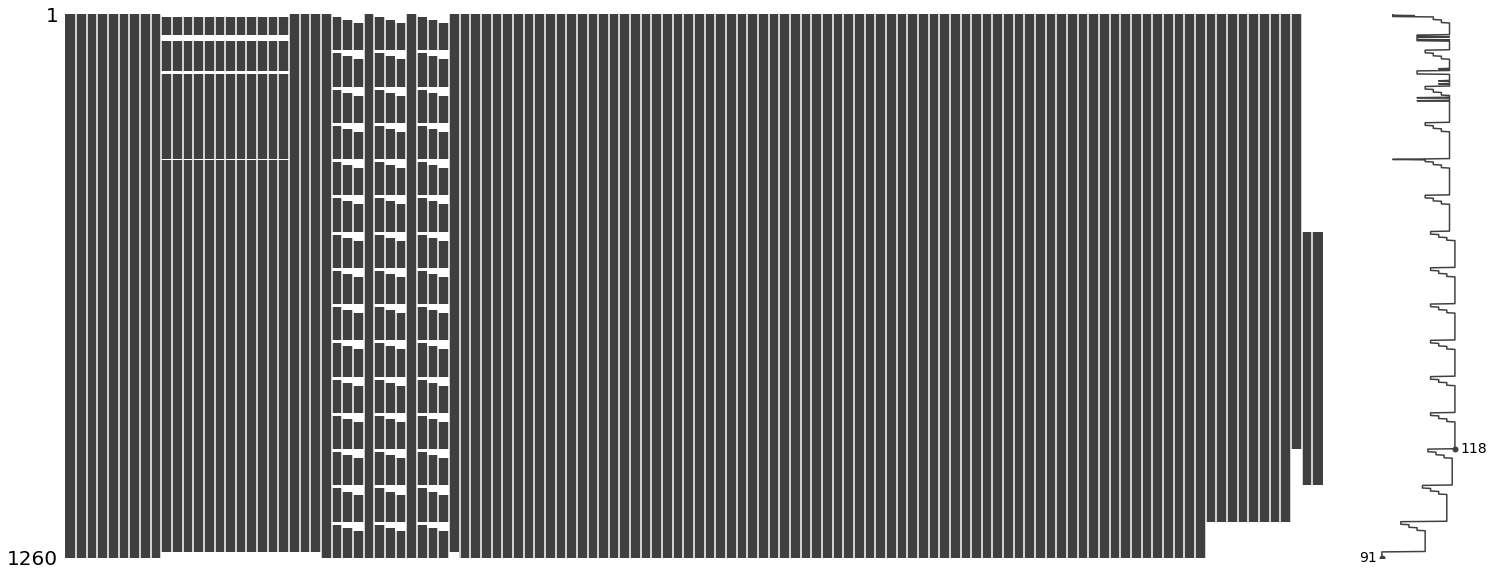

In [4]:
missingno.matrix(dataset_monthly)

In [5]:
missing = describe_dataframe(dataset_monthly, remove_zeros=True)
missing

,Column,Missing
0,ndvi,3.7302
1,ndmi,3.7302
2,ndwi,3.7302
3,ndbi,3.7302
4,ndvi_mean,3.4127
...,...,...
31,F_Y_GE65,6.6667
32,F_TOTAL,6.6667
33,MIO_EUR,20.0000
34,L_TOTAL,53.3333


In [6]:
years = dataset_monthly.year.unique()
nuts3_units = dataset_monthly.NUTS3_ID.unique()

In [9]:
data_p1 = []
data_p2 = []

for year in years[1:]:
    for region in nuts3_units:
        df_regional = dataset_monthly.loc[(dataset_monthly['NUTS3_ID'] == region)].copy()
        df_regional.reset_index(drop = True, inplace = True)

        df_period_1 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] == 1))].copy()
        df_period_2 = df_regional.loc[((df_regional['year'] == year-1) & (df_regional['month'] >= 11)) | ((df_regional['year'] == year) & (df_regional['month'] <= 4))].copy()
        #df_period_2 = df_regional.loc[(df_regional['year'] == 2011) & (df_regional['month'] >= 2) & (df_regional['month'] <= 4)].copy()
        df_prev_year = df_regional.loc[(df_regional['year'] == year-1)].copy()
        df_curr_year = df_regional.loc[(df_regional['year'] == year)].copy()

        x = df_curr_year['x'].mean()
        y = df_curr_year['y'].mean()

        ndvi_p1 = df_period_1['ndvi'].mean()
        ndwi_p1 = df_period_1['ndwi'].mean()
        ndmi_p1 = df_period_1['ndmi'].mean()
        ndbi_p1 = df_period_1['ndbi'].mean()

        ndvi_p2 = df_period_2['ndvi'].mean()
        ndwi_p2 = df_period_2['ndwi'].mean()
        ndmi_p2 = df_period_2['ndmi'].mean()
        ndbi_p2 = df_period_2['ndbi'].mean()
        #------------------------------------------------------
        lst_mean_p1 = df_period_1['lst_mean'].mean()
        lst_day_mean_p1 = df_period_1['lst_day_mean'].mean()
        lst_night_mean_p1 = df_period_1['lst_night_mean'].mean()
        lst_min_p1 = df_period_1['monthly_lst_min'].min()
        lst_max_p1 = df_period_1['monthly_lst_min'].max()

        lst_mean_p2 = df_period_2['lst_mean'].mean()
        lst_day_mean_p2 = df_period_2['lst_day_mean'].mean()
        lst_night_mean_p2 = df_period_2['lst_night_mean'].mean()
        lst_min_p2 = df_period_2['monthly_lst_min'].min()
        lst_max_p2 = df_period_2['monthly_lst_min'].max()
        #-------------------------------------------------------
        prec_mean_p1 = df_period_1['rainfall_mean'].mean()
        prec_acc_p1 = df_period_1['monthly_acc_prec'].sum()

        prec_mean_p2 = df_period_2['rainfall_mean'].mean()
        prec_acc_p2 = df_period_2['monthly_acc_prec'].sum()
        #-------------------------------------------------------
        mosq_mean_p1 = df_period_1['mosq_pred_mean'].mean()
        mosq_sum_p1 = df_period_1['mosq_pred_acc'].sum()

        mosq_mean_p2 = df_period_2['mosq_pred_mean'].mean()
        mosq_sum_p2 = df_period_2['mosq_pred_acc'].sum()
        #--------------------------------------------------------
        bio1 = df_prev_year.iloc[0]['bio1']
        bio2 = df_prev_year.iloc[0]['bio2']
        bio3 = df_prev_year.iloc[0]['bio3']
        bio4 = df_prev_year.iloc[0]['bio4']
        bio5 = df_prev_year.iloc[0]['bio5']
        bio6 = df_prev_year.iloc[0]['bio6']
        bio7 = df_prev_year.iloc[0]['bio7']
        bio8 = df_prev_year.iloc[0]['bio8']
        bio9 = df_prev_year.iloc[0]['bio9']
        bio10 = df_prev_year.iloc[0]['bio10']
        bio11 = df_prev_year.iloc[0]['bio11']
        bio12 = df_prev_year.iloc[0]['bio12']
        bio13 = df_prev_year.iloc[0]['bio13']
        bio14 = df_prev_year.iloc[0]['bio14']
        bio15 = df_prev_year.iloc[0]['bio15']
        bio16 = df_prev_year.iloc[0]['bio16']
        bio17 = df_prev_year.iloc[0]['bio17']
        bio18 = df_prev_year.iloc[0]['bio18']
        bio19 = df_prev_year.iloc[0]['bio19']
        #--------------------------------------------------------
        lc_prop1 = df_prev_year.iloc[0]['lc_prop1']
        lc_prop2 = df_prev_year.iloc[0]['lc_prop2']
        lc_prop3 = df_prev_year.iloc[0]['lc_prop3']
        lc_type1 = df_prev_year.iloc[0]['lc_type1']
        lc_type2 = df_prev_year.iloc[0]['lc_type2']
        lc_type3 = df_prev_year.iloc[0]['lc_type3']
        lc_type4 = df_prev_year.iloc[0]['lc_type4']
        lc_type5 = df_prev_year.iloc[0]['lc_type5']
        #--------------------------------------------------------
        distance_to_coast = df_prev_year.iloc[0]['distance_to_coast']
        distance_to_river = df_prev_year.iloc[0]['distance_to_river']
        slope_mean_1km = df_prev_year.iloc[0]['slope_mean_1km']
        aspect_mean_200m = df_prev_year.iloc[0]['aspect_mean_200m']
        elevation_mean_1km = df_prev_year.iloc[0]['elevation_mean_1km']
        hillshade_mean_1km = df_prev_year.iloc[0]['hillshade_mean_1km']
        fs_area_1km = df_prev_year.iloc[0]['fs_area_1km']
        flow_accu_200m = df_prev_year.iloc[0]['flow_accu_200m']

        distance_to_coast_std = df_prev_year.iloc[0]['distance_to_coast_std']
        distance_to_river_std = df_prev_year.iloc[0]['distance_to_river_std']
        slope_mean_1km_std = df_prev_year.iloc[0]['slope_mean_1km_std']
        aspect_mean_200m_std = df_prev_year.iloc[0]['aspect_mean_200m_std']
        elevation_mean_1km_std = df_prev_year.iloc[0]['elevation_mean_1km_std']
        hillshade_mean_1km_std = df_prev_year.iloc[0]['hillshade_mean_1km_std']
        fs_area_1km_std = df_prev_year.iloc[0]['fs_area_1km_std']
        flow_accu_200m_std = df_prev_year.iloc[0]['flow_accu_200m_std']
        #--------------------------------------------------------
        males_lt15 = df_prev_year.iloc[0]['M_Y_LT15']
        males_15t64 = df_prev_year.iloc[0]['M_Y15-64']
        males_gt65 = df_prev_year.iloc[0]['M_Y_GE65']
        males_total = df_prev_year.iloc[0]['M_TOTAL']

        females_lt15 = df_prev_year.iloc[0]['F_Y_LT15']
        females_15t64 = df_prev_year.iloc[0]['F_Y15-64']
        females_gt65 = df_prev_year.iloc[0]['F_Y_GE65']
        females_total = df_prev_year.iloc[0]['F_TOTAL']

        mio_eur = df_prev_year.iloc[0]['MIO_EUR']
        l_total = df_prev_year.iloc[0]['L_TOTAL']
        unl_total = df_prev_year.iloc[0]['UNL_TOTAL']
        #--------------------------------------------------------
        cases_total = df_curr_year['cases'].sum()
        cases_arr = df_curr_year.loc[(df_curr_year['month'] >= 5) & (df_curr_year['month'] <= 10)]['cases'].to_list()

        data_p1.append({'NUTS3_ID': region, 
                     'year': year, 
                     'x' : x,
                     'y': y,
                     'ndvi_p1': ndvi_p1,
                     'ndwi_p1': ndwi_p1,
                     'ndmi_p1': ndmi_p1,
                     'ndbi_p1': ndbi_p1,
                     'lst_mean_p1': lst_mean_p1,
                     'lst_day_mean_p1': lst_day_mean_p1,
                     'lst_night_mean_p1': lst_night_mean_p1,
                     'lst_min_p1': lst_min_p1,
                     'lst_max_p1': lst_max_p1,
                     'prec_mean_p1': prec_mean_p1,
                     'prec_acc_p1': prec_acc_p1,
                     'mosq_mean_p1': mosq_mean_p1,
                     'mosq_sum_p1': mosq_sum_p1,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })

        data_p2.append({'NUTS3_ID': region, 
                     'year': year,
                     'x' : x,
                     'y': y, 
                     'ndvi_p1': ndvi_p2,
                     'ndwi_p1': ndwi_p2,
                     'ndmi_p1': ndmi_p2,
                     'ndbi_p1': ndbi_p2,
                     'lst_mean_p1': lst_mean_p2,
                     'lst_day_mean_p1': lst_day_mean_p2,
                     'lst_night_mean_p1': lst_night_mean_p2,
                     'lst_min_p1': lst_min_p2,
                     'lst_max_p1': lst_max_p2,
                     'prec_mean_p1': prec_mean_p2,
                     'prec_acc_p1': prec_acc_p2,
                     'mosq_mean_p1': mosq_mean_p2,
                     'mosq_sum_p1': mosq_sum_p2,
                     'bio1': bio1,
                     'bio2': bio2,
                     'bio3': bio3,
                     'bio4': bio4,
                     'bio5': bio5,
                     'bio6': bio6,
                     'bio7': bio7,
                     'bio8': bio8,
                     'bio9': bio9,
                     'bio10': bio10,
                     'bio11': bio11,
                     'bio12': bio12,
                     'bio13': bio13,
                     'bio14': bio14,
                     'bio15': bio15,
                     'bio16': bio16,
                     'bio17': bio17,
                     'bio18': bio18,
                     'bio19': bio19,
                     'lc_prop1': lc_prop1,
                     'lc_prop2': lc_prop2,
                     'lc_prop3': lc_prop3,
                     'lc_type1': lc_type1,
                     'lc_type2': lc_type2,
                     'lc_type3': lc_type3,
                     'lc_type4': lc_type4,
                     'lc_type5': lc_type5,
                     'distance_to_coast': distance_to_coast,
                     'distance_to_river': distance_to_river,
                     'slope_mean_1km': slope_mean_1km,
                     'aspect_mean_200m': aspect_mean_200m,
                     'elevation_mean_1km': elevation_mean_1km,
                     'hillshade_mean_1km': hillshade_mean_1km,
                     'fs_area_1km': fs_area_1km,
                     'flow_accu_200m': flow_accu_200m,
                     'distance_to_coast_std': distance_to_coast_std,
                     'distance_to_river_std': distance_to_river_std,
                     'slope_mean_1km_std': slope_mean_1km_std,
                     'aspect_mean_200m_std': aspect_mean_200m_std,
                     'elevation_mean_1km_std': elevation_mean_1km_std,
                     'hillshade_mean_1km_std': hillshade_mean_1km_std,
                     'fs_area_1km_std': fs_area_1km_std,
                     'flow_accu_200m_std': flow_accu_200m_std,
                     'males_lt15': males_lt15,
                     'males_15t64': males_15t64,
                     'males_gt65': males_gt65,
                     'males_total': males_total,
                     'females_lt15': females_lt15,
                     'females_15t64': females_15t64,
                     'females_gt65': females_gt65,
                     'females_total': females_total,
                     'mio_eur': mio_eur,
                     'l_total': l_total,
                     'unl_total': unl_total,
                     'mio_eur': mio_eur,
                     'cases_total': cases_total,
                     'cases_arr': cases_arr,
                     })
        
p1_df = pd.DataFrame(data_p1)       
p2_df = pd.DataFrame(data_p2) 

In [11]:
p1_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL301,2010,23.825080,38.055971,0.251207,-0.099001,0.127109,-0.127109,11.270085,14.307629,8.232541,0.006000,6.424667,4.696416,433.951760,23.411876,2176.066667,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
1,EL302,2010,23.686502,38.024894,0.129373,-0.069864,0.065394,-0.065394,13.022827,16.051113,9.994542,1.254000,8.742000,4.611694,426.116110,28.092688,2611.000000,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,39132.0,180473.0,33120.0,252725.0,36806.0,177964.0,43801.0,258571.0,7725.12,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
2,EL303,2010,23.757527,37.973503,0.168791,0.001886,0.133274,-0.133274,12.472471,15.338536,9.606405,0.504000,8.140000,4.335368,400.526707,25.724337,2390.900000,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,1,9,1,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,65801.0,384275.0,78826.0,528902.0,62294.0,394771.0,118140.0,575205.0,42230.54,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL304,2010,23.745366,37.906427,0.185359,-0.076298,0.100599,-0.100599,12.456371,15.330502,9.582240,-3.221429,8.458571,4.204112,388.377636,28.069227,2608.714286,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,32,9,30,13,13,10,8,9,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,1102.518301,546.203305,2.811541,27.629915,67.403274,8.773781,0.000000,7.784344,39069.0,184842.0,40118.0,264029.0,36883.0,199704.0,54439.0,291026.0,13339.20,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
4,EL305,2010,23.886562,38.040564,0.372076,-0.177236,0.146473,-0.146473,11.261248,14.337411,8.185085,1.637879,7.220572,4.648168,429.419641,23.281501,2163.784512,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,31,30,30,10,10,1,6,6,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,3466.704589,1186.512044,7.140049,48.230147,206.413858,8.757546,0.069070,203.384653,41876.0,176906.0,33787.0,252569.0,39627.0,167626.0,37127.0,244380.0,13475.35,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

In [12]:
p2_df

,NUTS3_ID,year,x,y,ndvi_p1,ndwi_p1,ndmi_p1,ndbi_p1,lst_mean_p1,lst_day_mean_p1,lst_night_mean_p1,lst_min_p1,lst_max_p1,prec_mean_p1,prec_acc_p1,mosq_mean_p1,mosq_sum_p1,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases_total,cases_arr
0,EL301,2010,23.825080,38.055971,0.235768,-0.123003,0.106146,-0.106146,12.600325,16.407270,8.793381,-0.235333,8.218000,3.500938,634.127267,32.670400,5952.866667,19.000000,19.166667,42.592593,920.721061,45.0,0.0,45.0,8.333333,30.666667,30.666667,8.333333,1230.0,227.0,9.0,72.351252,546.0,54.0,54.0,546.0,22,9,20,13,13,10,8,9,12596.173352,1653.260278,7.066667,199.653520,293.515429,186.164165,0.000000,11.320098,2296.456415,1184.432609,4.682287,23.874457,92.528119,3.668097,0.000000,21.863192,45632.0,201617.0,45952.0,293201.0,43321.0,220852.0,58521.0,322694.0,19823.63,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
1,EL302,2010,23.686502,38.024894,0.119498,-0.100140,0.042116,-0.042116,14.318019,18.266135,10.369904,1.254000,10.506000,3.445517,624.361789,47.367675,8625.000000,20.791667,18.916667,42.992424,928.453830,46.0,2.0,44.0,9.833333,33.000000,33.000000,9.833333,1216.0,229.0,10.0,72.746381,538.0,55.0,55.0,538.0,1,9,1,13,13,10,8,9,7495.493496,2041.783345,2.800000,135.961772,107.413199,175.185410,0.000000,5.799639,1549.348962,1081.112134,1.788854,12.696343,30.830096,4.405654,0.000000,2.978368,39132.0,180473.0,33120.0,252725.0,36806.0,177964.0,43801.0,258571.0,7725.12,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
2,EL303,2010,23.757527,37.973503,0.166671,-0.053801,0.099007,-0.099007,13.793941,17.415481,10.172400,0.504000,9.916000,3.327994,601.667354,40.637125,7402.900000,19.875000,18.250000,43.452381,879.081390,44.0,2.0,42.0,9.833333,31.333333,31.333333,9.833333,1175.0,208.0,5.0,73.228177,521.0,47.0,47.0,521.0,1,9,1,13,13,10,8,9,7451.460209,1907.131239,7.200000,218.497003,207.330391,190.939862,0.000000,2.773017,1461.964111,1273.662642,4.211096,30.940738,139.781885,8.039500,0.000000,1.621831,65801.0,384275.0,78826.0,528902.0,62294.0,394771.0,118140.0,575205.0,42230.54,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
3,EL304,2010,23.745366,37.906427,0.174811,-0.105832,0.079507,-0.079507,13.940576,17.470481,10.410672,-3.221429,10.367143,3.233481,584.358127,46.694903,8503.714286,19.291667,18.250000,42.441860,874.761872,43.0,0.0,43.0,9.666667,30.666667,30.666667,9.333333,1156.0,200.0,3.0,74.022313,512.0,41.0,41.0,456.0,32,9,30,13,13,10,8,9,2626.770961,1089.712354,6.285714,221.663863,97.544439,189.577626,0.000000,5.864646,1102.518301,546.203305,2.811541,27.629915,67.403274,8.773781,0.000000,7.784344,39069.0,184842.0,40118.0,264029.0,36883.0,199704.0,54439.0,291026.0,13339.20,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
4,EL305,2010,23.886562,38.040564,0.374931,-0.206851,0.138474,-0.138474,12.292978,16.462568,8.123387,-0.211145,7.364747,3.501007,633.544719,30.596578,5580.289562,18.708333,19.916667,44.259259,885.093301,45.0,0.0,45.0,9.000000,29.833333,29.833333,8.333333,1231.0,223.0,7.0,72.756797,539.0,47.0,47.0,467.0,31,30,30,10,10,1,6,6,5611.983975,1700.571082,9.356902,167.034553,251.967998,178.128437,0.004394,36.564396,3466.704589,1186.512044,7.140049,48.230147,206.413858,8.757546,0.069070,203.384653,41876.0,176906.0,33787.0,252569.0,39627.0,167626.0,37127.0,244380.0,13475.35,NaN,NaN,0,"[0, 0, 0, 0, 0, 0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,..

<AxesSubplot:>

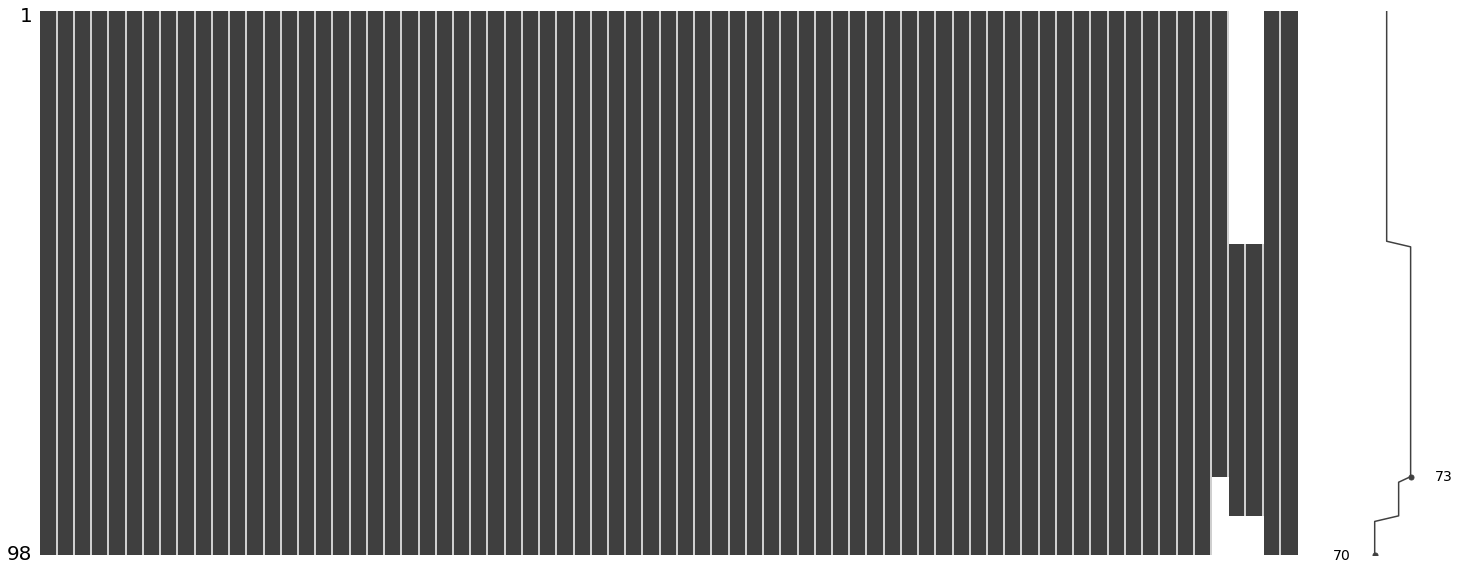

In [13]:
missingno.matrix(p1_df)

<AxesSubplot:>

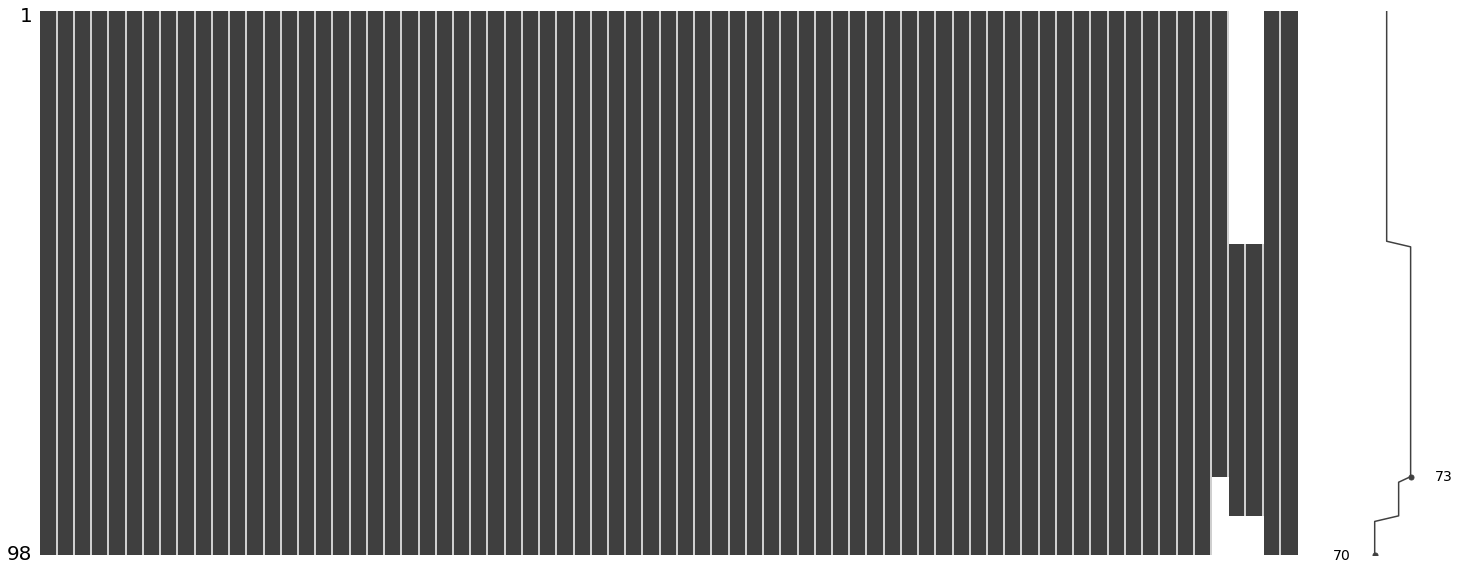

In [14]:
missingno.matrix(p2_df)

In [15]:
missing = describe_dataframe(p1_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,14.2857
1,l_total,50.0000
2,unl_total,50.0000


In [16]:
missing = describe_dataframe(p2_df, remove_zeros=True)
missing

,Column,Missing
0,mio_eur,14.2857
1,l_total,50.0000
2,unl_total,50.0000


In [17]:
p1_df.cases_total.sum()

296

In [18]:
p2_df.cases_total.sum()

296

In [19]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'mio_eur']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['mio_eur']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [20]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'l_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['l_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

In [21]:
imputer = KNNImputer()

knn_imputer_columns = ['x', 'y', 'year', 'unl_total']

temp_df = p1_df[knn_imputer_columns]

imputed_data = pd.DataFrame(imputer.fit_transform(temp_df), columns = temp_df.columns)

imputed_columns = ['unl_total']

p1_df[imputed_columns] = imputed_data[imputed_columns]
p2_df[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

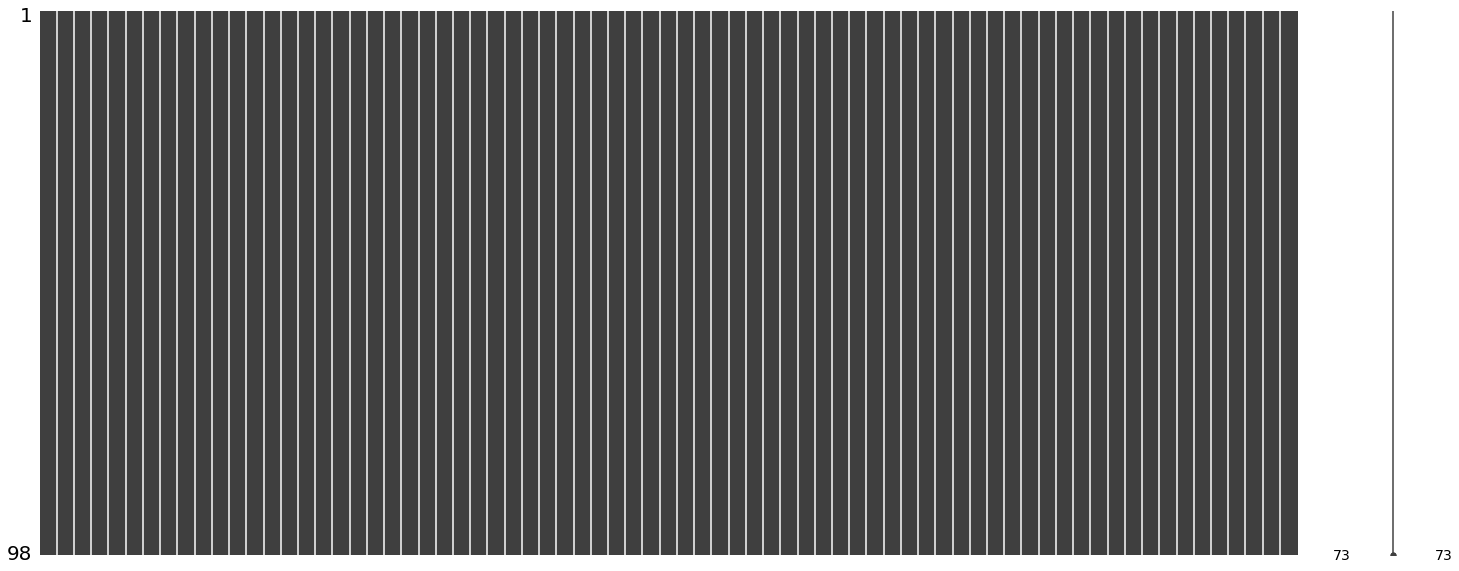

In [22]:
missingno.matrix(p1_df, label_rotation=90)

<AxesSubplot:>

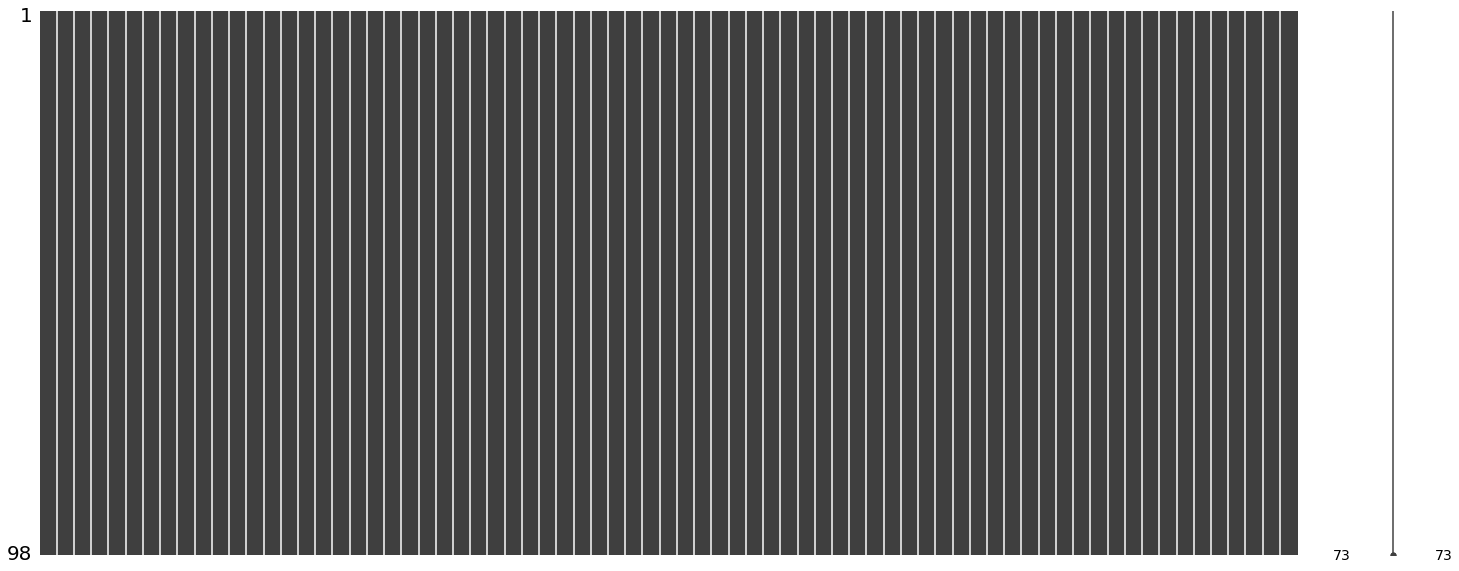

In [20]:
missingno.matrix(p2_df, label_rotation=90)

<AxesSubplot:>

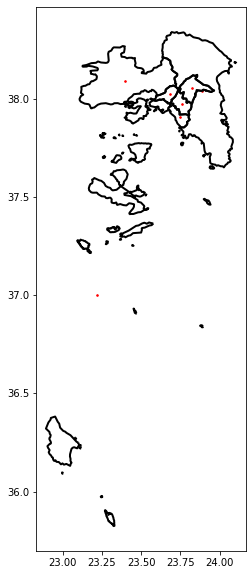

In [23]:
## Reading shapefiles from Greece

greece_nuts3_gdf = gpd.read_file(f"../../../../Europe NUTS - LAU/Greece/data/EL_Whole.shp",  encoding=enc)

greece_nuts3_gdf = greece_nuts3_gdf.to_crs(epsg=4326)

nuts3_gdf = greece_nuts3_gdf[greece_nuts3_gdf['NUTS2_ID'] == f'{NUTS2_ID}']

nuts3_points = gpd.GeoDataFrame(p1_df[['NUTS3_ID']], geometry=gpd.points_from_xy(p1_df.x, p1_df.y))

ax = nuts3_points.head(7).plot(markersize=2.5, figsize=(10, 10), color='red')
nuts3_gdf.plot(facecolor="none", edgecolor='black', ax=ax, lw=2)

In [24]:
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P1_2010_2023.csv", encoding = enc, index = False)
p1_df.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_P2_2010_2023.csv", encoding = enc, index = False)